In [19]:
import pandas as pd

file_path = "/Users/laurelchang/Downloads/810 sample Data/sf-loan-performance-data-sample.csv"

df = pd.read_csv(
    file_path,
    sep="|",
    engine="python",
    header=None
)

print("Raw shape:", df.shape)
display(df.head(5))

Raw shape: (757, 108)


,0,1,2,3,4,5,6,7,8,9,...,98,99,100,101,102,103,104,105,106,107
0,NaN,100023020488,82009,R,Other,Other,NaN,5.375,5.375,55000.0,...,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN
1,NaN,100023020488,92009,R,Other,Other,NaN,5.375,5.375,55000.0,...,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN
2,NaN,100023020488,102009,R,Other,Other,NaN,5.375,5.375,55000.0,...,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN
3,NaN,100023020488,112009,R,Other,Other,NaN,5.375,5.375,55000.0,...,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN
4,NaN,100023020488,122009,R,Other,Other,NaN,5.375,5.375,55000.0,...,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN


In [21]:
if df.iloc[:, 0].isna().mean() > 0.95:
    df = df.iloc[:, 1:].copy()

print("After drop empty leading col:", df.shape)
display(df.head(5))

After drop empty leading col: (757, 107)


,1,2,3,4,5,6,7,8,9,10,...,98,99,100,101,102,103,104,105,106,107
0,100023020488,82009,R,Other,Other,NaN,5.375,5.375,55000.0,NaN,...,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN
1,100023020488,92009,R,Other,Other,NaN,5.375,5.375,55000.0,NaN,...,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN
2,100023020488,102009,R,Other,Other,NaN,5.375,5.375,55000.0,NaN,...,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN
3,100023020488,112009,R,Other,Other,NaN,5.375,5.375,55000.0,NaN,...,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN
4,100023020488,122009,R,Other,Other,NaN,5.375,5.375,55000.0,NaN,...,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN


In [22]:
!pip install pdfplumber

In [23]:
import re
import pdfplumber

pdf_path = "/Users/laurelchang/Downloads/crt-file-layout-and-glossary.pdf"

pos_to_name = {}

with pdfplumber.open(pdf_path) as pdf:
    for page in pdf.pages:
        
        table = page.extract_table()
        if table:
            for row in table:
                if not row or len(row) < 2:
                    continue
                pos = (row[0] or "").strip()
                name = (row[1] or "").strip()
                if pos.isdigit() and name:
                    p = int(pos)
                    if 1 <= p <= 200:
                        pos_to_name.setdefault(p, name)
        else:
           
            txt = page.extract_text() or ""
            for m in re.finditer(r"(?m)^\s*(\d{1,3})\s+([A-Za-z][A-Za-z0-9 /().,\-]*?)\s*$", txt):
                p = int(m.group(1))
                name = m.group(2).strip()
                if 1 <= p <= 200:
                    pos_to_name.setdefault(p, name)

field_names = [pos_to_name.get(i, f"field_{i:03d}") for i in range(1, 109)]

print("Field names extracted:", sum(1 for x in field_names if not x.startswith("field_")), "/ 108")
missing = [i for i in range(1, 109) if pos_to_name.get(i) is None]
print("Missing positions:", missing[:30], ("... total " + str(len(missing)) if len(missing) > 30 else ""))
print("First 15 field names:", field_names[:15])

Field names extracted: 108 / 108
Missing positions: [] 
First 15 field names: ['Reference Pool ID', 'Loan Identifier', 'Monthly Reporting Period', 'Channel', 'Seller Name', 'Servicer Name', 'Master Servicer', 'Original Interest Rate', 'Current Interest Rate', 'Original UPB', 'UPB at Issuance', 'Current Actual UPB', 'Original Loan Term', 'Origination Date', 'First Payment Date']


In [24]:
# df = your current DataFrame
# field_names = the 108 header names you extracted from the PDF (list of length 108)

import pandas as pd

# 1) sanity check
print("df shape:", df.shape)
print("field_names:", len(field_names))

# 2) assign headers (handles the common “leading empty column” case)
if df.shape[1] == len(field_names):
    df.columns = field_names

elif df.shape[1] == len(field_names) - 1:
    # df is missing the first field (often because you dropped the leading empty column)
    df.columns = field_names[1:]

elif df.shape[1] == len(field_names) + 1:
    # df has an extra leading empty column (often all-NaN)
    # drop the first column, then assign
    df = df.iloc[:, 1:].copy()
    df.columns = field_names

else:
    raise ValueError(f"Column mismatch: df has {df.shape[1]} cols, headers have {len(field_names)}")

display(df.head(5))


df shape: (757, 107)
field_names: 108


,Loan Identifier,Monthly Reporting Period,Channel,Seller Name,Servicer Name,Master Servicer,Original Interest Rate,Current Interest Rate,Original UPB,UPB at Issuance,...,Mortgage Margin,ARM Balloon Indicator,ARM Plan Number,Borrower Assistance Plan,High Loan to Value (HLTV)\nRefinance Option Indicator,Deal Name,Repurchase Make Whole Proceed,Alternative Delinquency Resolution,Alternative Delinquency\nResolution Count,Total Deferral Amount
0,100023020488,82009,R,Other,Other,NaN,5.375,5.375,55000.0,NaN,...,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN
1,100023020488,92009,R,Other,Other,NaN,5.375,5.375,55000.0,NaN,...,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN
2,100023020488,102009,R,Other,Other,NaN,5.375,5.375,55000.0,NaN,...,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN
3,100023020488,112009,R,Other,Other,NaN,5.375,5.375,55000.0,NaN,...,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN
4,100023020488,122009,R,Other,Other,NaN,5.375,5.375,55000.0,NaN,...,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN


In [27]:
!pip install rasterio matplotlib numpy pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.8/22.8 MB 14.3 MB/s  0:00:01 14.7 MB/s eta 0:00:01
  Attempting uninstall: click
    Found existing installation: click 8.2.1
    Uninstalling click-8.2.1:
      Successfully uninstalled click-8.2.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [rasterio]━━ 3/4 [rasterio]


In [28]:
!pip install contextily geopandas shapely pyproj

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 18.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 13.8 MB/s  0:00:00 22.7 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 15.7 MB/s  0:00:01a 0:00:010:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [contextily] 6/8 [geopandas]


In [30]:
import os

folder = "/Users/laurelchang/Downloads/810 sample Data/AISVesselTransitCounts2024"

files = sorted(os.listdir(folder))
for f in files:
    print(f)

AISVTC2024Atlantic.tfw
AISVTC2024Atlantic.tif
AISVTC2024Atlantic.tif.aux.xml
AISVTC2024Atlantic.tif.ovr
AISVTC2024Atlantic.tif.xml
AISVTC2024GreatLakes.tfw
AISVTC2024GreatLakes.tif
AISVTC2024GreatLakes.tif.aux.xml
AISVTC2024GreatLakes.tif.ovr
AISVTC2024GreatLakes.tif.xml
AISVTC2024GulfOfMexico.tfw
AISVTC2024GulfOfMexico.tif
AISVTC2024GulfOfMexico.tif.aux.xml
AISVTC2024GulfOfMexico.tif.ovr
AISVTC2024GulfOfMexico.tif.xml
AISVTC2024Pacific.tfw
AISVTC2024Pacific.tif
AISVTC2024Pacific.tif.aux.xml
AISVTC2024Pacific.tif.ovr
AISVTC2024Pacific.tif.xml
AISVTC2024WestCoast.tfw
AISVTC2024WestCoast.tif
AISVTC2024WestCoast.tif.aux.xml
AISVTC2024WestCoast.tif.ovr
AISVTC2024WestCoast.tif.xml


In [31]:
import os
from pathlib import Path

folder = Path("/Users/laurelchang/Downloads/810 sample Data/AISVesselTransitCounts2024")

tifs = sorted(folder.glob("*.tif"))
print("Found .tif files:", [t.name for t in tifs])

tif_path = str(tifs[0])  # pick the first one
print("Using:", tif_path)

Found .tif files: ['AISVTC2024Atlantic.tif', 'AISVTC2024GreatLakes.tif', 'AISVTC2024GulfOfMexico.tif', 'AISVTC2024Pacific.tif', 'AISVTC2024WestCoast.tif']
Using: /Users/laurelchang/Downloads/810 sample Data/AISVesselTransitCounts2024/AISVTC2024Atlantic.tif


In [34]:
import rasterio
import numpy as np

with rasterio.open(tif_path) as src:
    print("CRS:", src.crs)
    print("Size (W x H):", src.width, "x", src.height)
    print("Bands:", src.count)
    print("Dtype:", src.dtypes[0])
    print("NoData:", src.nodata)
    print("Bounds:", src.bounds)
    print("Resolution:", src.res)

    arr = src.read(1)

print("Array shape:", arr.shape)
print("Min/Max:", arr.min(), arr.max())
print("Nonzero cells:", (arr > 0).sum(), "/", arr.size)

CRS: EPSG:3857
Size (W x H): 26825 x 39646
Bands: 1
Dtype: uint32
NoData: 0.0
Bounds: BoundingBox(left=-9361969.7374, bottom=1711478.3931999998, right=-6679469.737400001, top=5676078.3932)
Resolution: (100.0, 100.0)
Array shape: (39646, 26825)
Min/Max: 0 90474
Nonzero cells: 127050855 / 1063503950


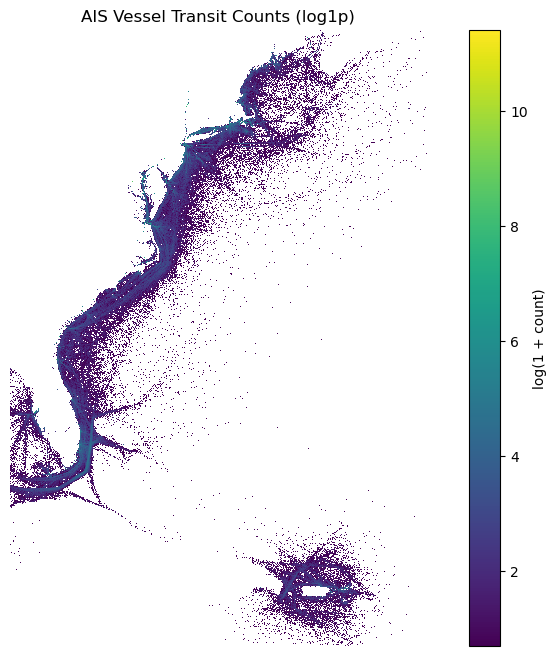

In [33]:
import matplotlib.pyplot as plt
import numpy as np

plot_arr = arr.astype(float)
plot_arr[plot_arr <= 0] = np.nan

plt.figure(figsize=(11, 8))
plt.imshow(np.log1p(plot_arr), interpolation="nearest")
plt.title("AIS Vessel Transit Counts (log1p)")
plt.colorbar(label="log(1 + count)")
plt.axis("off")
plt.show()

In [35]:
import pandas as pd

nonzero = arr[arr > 0]
s = pd.Series(nonzero)

display(s.describe(percentiles=[0.5, 0.9, 0.95, 0.99]).to_frame("TransitCount (nonzero)"))

,TransitCount (nonzero)
count,1.270509e+08
mean,1.170221e+01
std,1.601611e+02
min,1.000000e+00
50%,3.000000e+00
90%,1.600000e+01
95%,2.800000e+01
99%,9.900000e+01
max,9.047400e+04


In [36]:
!pip install contextily

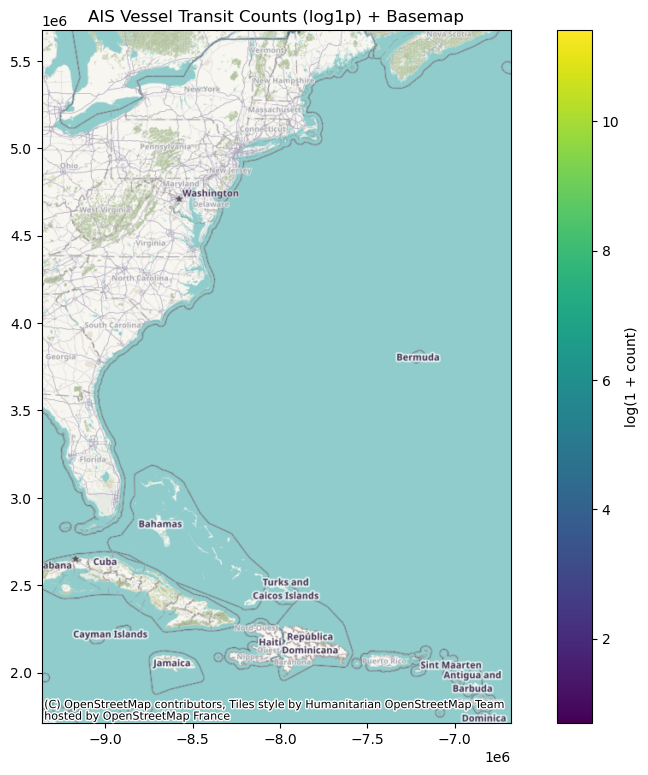

In [37]:
import contextily as cx
import rasterio
import numpy as np
import matplotlib.pyplot as plt

with rasterio.open(tif_path) as src:
    arr = src.read(1).astype(float)
    arr[arr <= 0] = np.nan
    extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
    crs = src.crs

fig, ax = plt.subplots(figsize=(12, 9))
im = ax.imshow(np.log1p(arr), extent=extent, origin="upper")
cx.add_basemap(ax, crs=crs)
ax.set_title("AIS Vessel Transit Counts (log1p) + Basemap")
fig.colorbar(im, ax=ax, label="log(1 + count)")
plt.show()